<div class='alert alert-block alert-info"'>
<h1> An sdg4varselect example :</h1>

<h4> Estimation in an Mixed-effect models </h4>

In [1]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

sdgplt.FIGSIZE = 10

### Model Specification

First, let's define the model with the abstract object AbstractMixedEffectsModel. We want to define the following logisitc models :

$$ \left\{\begin{array}{rll}
            Y_{i,j} &= m(t_{i,j}; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $m(t_{i,j}; \varphi_i) = \frac{\varphi_{1,i}}{1+\exp\left(\frac{\varphi_{2,i}-t_{i,j}}{\tau} \right)}$ 

In [2]:
# pylint: disable=C0116, W0221
import functools
from jax import jit
import parametrization_cookbook.jax as pc

from sdg4varselect.models import AbstractMixedEffectsModel


class LogisticMixedEffectsModel(AbstractMixedEffectsModel):
    """define a logistic mixed effects model"""

    def __init__(self, N=1, J=1, **kwargs):
        super().__init__(
            N=N,
            J=J,
            me_name=["phi1", "phi2"],
            **kwargs,
        )

        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                asymptotic=pc.RealPositive(scale=100),
                inflexion=pc.Real(loc=100, scale=100),
            ),
            tau=pc.RealPositive(scale=100),
            cov_latent=pc.MatrixSymPosDef(dim=2, scale=(200, 200)),
            var_residual=pc.RealPositive(scale=100),
        )

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        phi1: jnp.ndarray,  # shape = (N,) [:,None]
        phi2: jnp.ndarray,  # shape = (N,) [:,None]
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)
        """logistic_curve
        phi1 = asymptotic
        phi2 = inflexion
        """

        out = phi1[:, None] / (1 + jnp.exp(-(times - phi2[:, None]) / params.tau))
        assert out.shape == times.shape
        return out

    # ============================================================== #

    def sample(
        self,
        params_star,
        prngkey,
        **kwargs,
    ):
        """Sample one data set for the model"""

        (
            prngkey_time,
            prngkey_mem,
        ) = jrd.split(prngkey, num=2)

        # === nlmem_simulation() === #
        time = jnp.linspace(100, 1500, self.J)
        time = jnp.tile(time, (self.N, 1))
        time += 10 * jrd.uniform(prngkey_time, minval=-2, maxval=2, shape=time.shape)

        obs, sim = AbstractMixedEffectsModel.sample(
            self, params_star, prngkey_mem, mem_obs_time=time
        )

        return {"mem_obs_time": time} | obs, sim

### Data Generation
Then we can generate a data set with $N=1000$ individuals and $J=20$ observation time per individuals

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


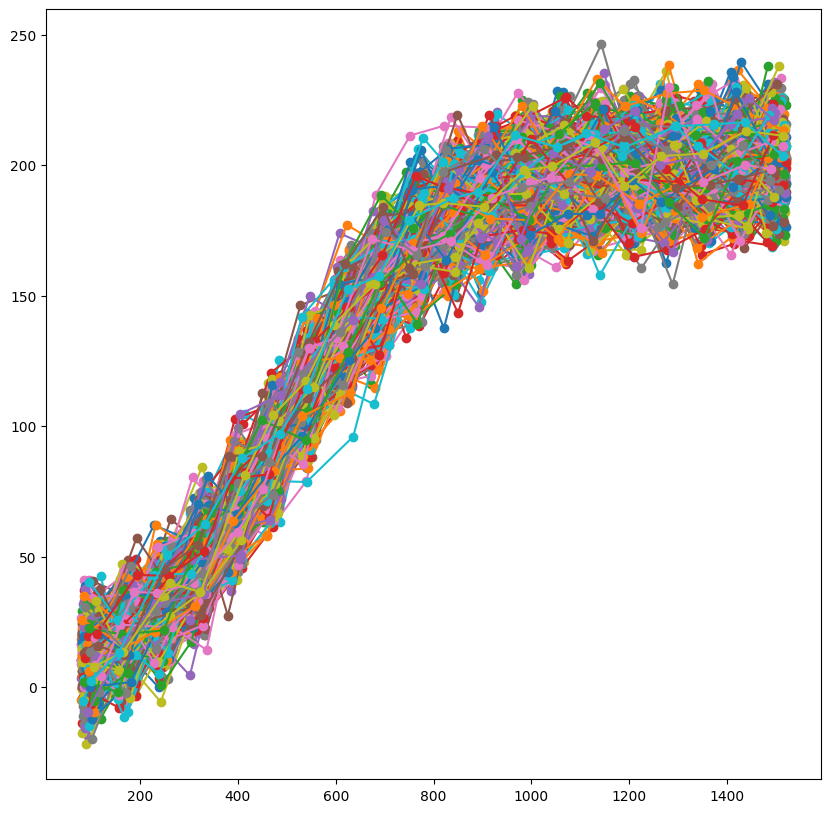

In [3]:
myModel = LogisticMixedEffectsModel(N=1000, J=20)

p_star = myModel.new_params(
    mean_latent={"asymptotic": 200, "inflexion": 500},
    tau=150,
    cov_latent=jnp.diag(jnp.array([40, 100])),
    var_residual=100,
)

myobs, mysim = myModel.sample(p_star, jrd.PRNGKey(0))

fig = sdgplt.figure()
ax = fig.add_subplot(1, 1, 1)
_ = ax.plot(myobs["mem_obs_time"].T, myobs["Y"].T, "o-")

# Estimation example

Let's do an estimation of the parameter with the SGD-FIM algorithm

first we need to intiate the algorithm with accurate step size.

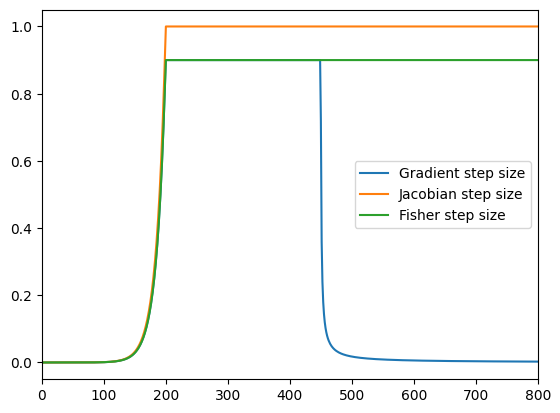

In [4]:
from sdg4varselect.outputs import GDResults, MultiRunRes
from sdg4varselect.algo import SGD_FIM, get_GDFIM_settings
from sdg4varselect.learning_rate import create_multi_step_size

algo_settings = get_GDFIM_settings(preheating=200, heating=450, learning_rate=1e-6)
step_sizes = create_multi_step_size(list(algo_settings))
labels = ["Gradient step size", "Jacobian step size", "Fisher step size"]
[lr.plot(label=labels[i]) for i, lr in enumerate(step_sizes)]
sdgplt.plt.legend()
_ = sdgplt.plt.xlim(0, 800)

We define a function that make one estimation run. we set $\varphi_1$ and $\varphi_2$ as latente variable, and use a MCMC-procedure in the algorithm to treat them :

In [5]:
def one_estim(prngkey, model, data, save_all=True):
    prngkey_theta, prngkey_estim = jrd.split(prngkey)
    theta0 = 0.2 * jrd.normal(prngkey_theta, shape=(model.parametrization.size,))

    algo = SGD_FIM(prngkey_estim, 10000, algo_settings)
    # =================== MCMC configuration ==================== #
    algo.init_mcmc(theta0, model, sd={"phi1": 5, "phi2": 20})

    algo.latent_variables["phi1"].adaptative_sd = True
    algo.latent_variables["phi2"].adaptative_sd = True
    # ==================== END configuration ==================== #
    res = algo.fit(model, data, theta0, ntry=5, partial_fit=False, save_all=save_all)

    for var in algo.latent_variables.values():
        sdgplt.plot(var)

    return res  # , algo

Now we perform severals estimations : 

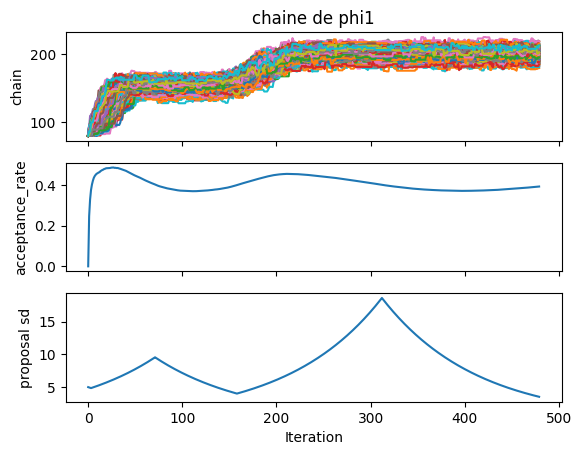

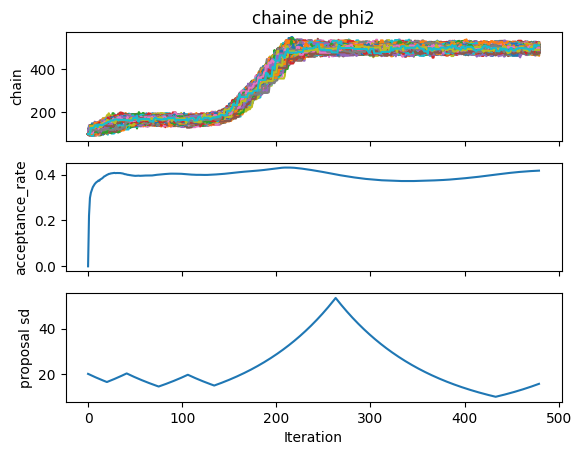

In [6]:
multi_estim = MultiRunRes(
    [one_estim(jrd.PRNGKey(key), myModel, myobs, save_all=True) for key in range(1)]
)

We can obtain the calculation time

In [8]:
print(multi_estim.chrono)

0:01:16.946515


And plot the results

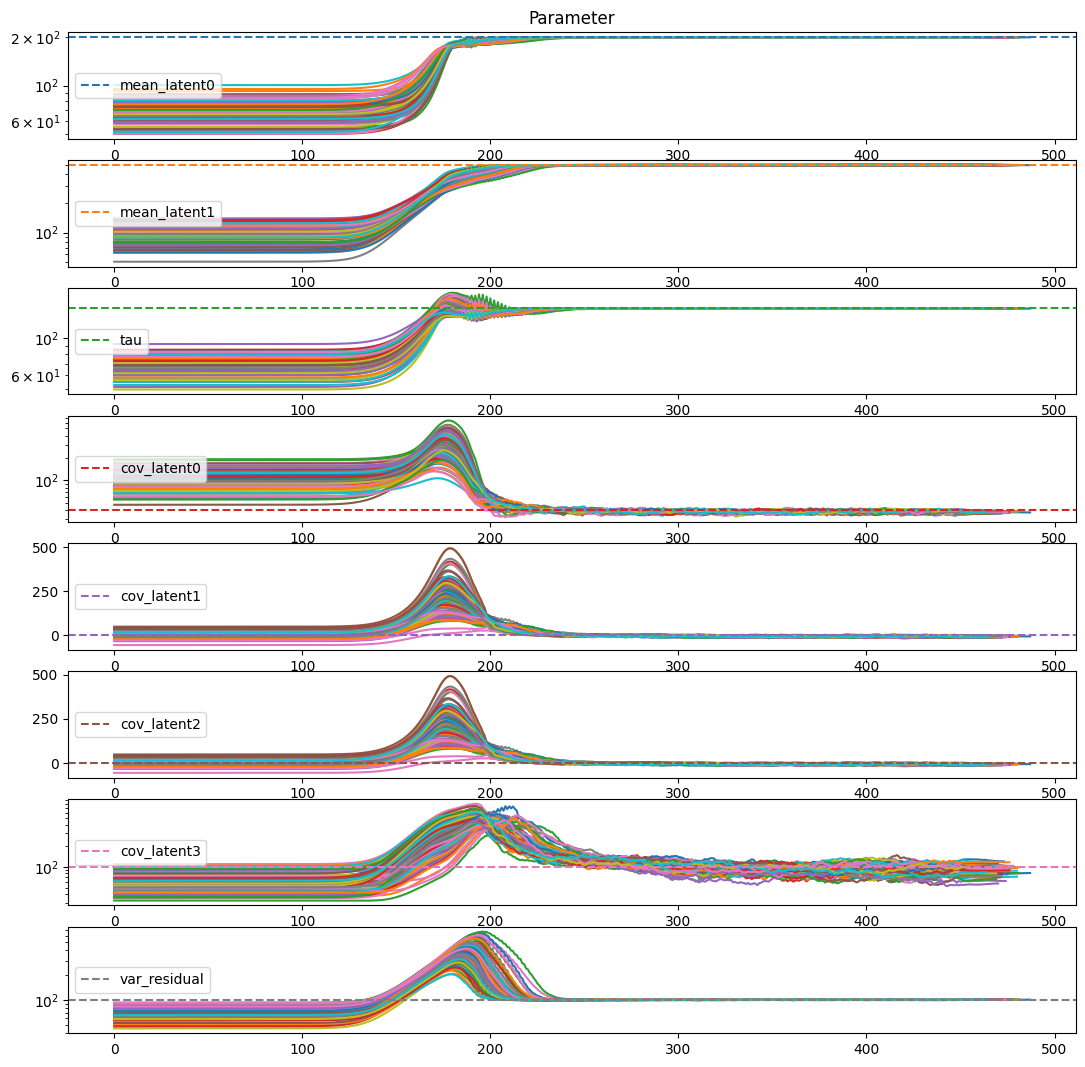

In [9]:
# === PLOT === #
sdgplt.FIGSIZE = 13

fig, axs = sdgplt.plot(
    multi_estim,
    params_star=myModel.hstack_params(p_star),
    params_names=myModel.params_names,
)

for i in [0, 1, 2, 3, 6, 7]:
    axs[i].set_yscale("log")

In [10]:
import pandas as pd

rmse = jnp.sqrt(
    ((jnp.array(multi_estim.last_theta) - myModel.hstack_params(p_star)) ** 2).mean(
        axis=0
    )
)
pd.DataFrame(
    jnp.array([rmse, jnp.array(multi_estim.last_theta).mean(axis=0)]).T,
    columns=["rmse", "value"],
    index=myModel.params_names,
)

,rmse,value
mean_latent0,0.130231,200.097560
mean_latent1,0.402027,499.882146
tau,0.328752,149.711467
cov_latent0,2.360953,37.791467
cov_latent1,6.807537,-6.258645
cov_latent2,6.807537,-6.258645
cov_latent3,16.300640,89.044639
var_residual,0.967637,100.941576
